# Correlation between the number of Characters nicknames and their popularity
In this file, we will try to check whether an anime character is more popular, the more nicknames he/she has.
We will do the analysis by taking the 'favorites' counter for each character in the database (it counts how many people set that character as their favorite) and comparing it with the number of different names that character has.
We wanted to bring this analysis because we were curious about a correlation that seems "logic", but is not obvious at all.

In [1]:
import pandas as pd
from lib import readSaveCsv
import matplotlib.pyplot as plt
import seaborn as sns

from lib.dbconnection import create_db_engine

engine = create_db_engine()

favs = readSaveCsv.import_data(engine, "favs")
ch_nicknames = readSaveCsv.import_data(engine, "character_nicknames")

Successo: Dati letti correttamente.
Successo: Dati letti correttamente.


In [2]:
ch_nicknames = ch_nicknames[["character_mal_id", 'nickname']]
ch_nicknames.head()
nof_nicknames = ch_nicknames['character_mal_id'].value_counts()

nof_nicknames

character_mal_id
17244     10
2030       9
673        8
13784      8
80891      8
          ..
279657     1
279655     1
279652     1
279651     1
280058     1
Name: count, Length: 30267, dtype: int64

In [3]:
favorites = favs[favs['fav_type'] == 'character']
favorites

,username,fav_type,id
9,ishikawas,character,172491
10,ishikawas,character,109929
11,ishikawas,character,1046
12,ishikawas,character,13045
13,ishikawas,character,2780
...,...,...,...
4178738,vincent0607,character,497
4178739,vincent0607,character,118739
4178740,vincent0607,character,188177
4178741,vincent0607,character,141354


In [4]:
favorites = favorites['id'].value_counts()

favorites

id
417       20819
40        16025
35252     14184
422       13663
672       12548
          ...  
7459          1
201805        1
5007          1
180060        1
48069         1
Name: count, Length: 36098, dtype: int64

In [5]:
result = pd.merge(nof_nicknames, favorites, left_on='character_mal_id', right_on='id', how='inner')

result.rename(columns={'count_x': 'nof_nicknames', 'count_y':'favs'}, inplace=True)

result

,nof_nicknames,favs
0,10,225
1,9,741
2,8,146
3,8,786
4,8,654
...,...,...
10858,1,1371
10859,1,1
10860,1,427
10861,1,1


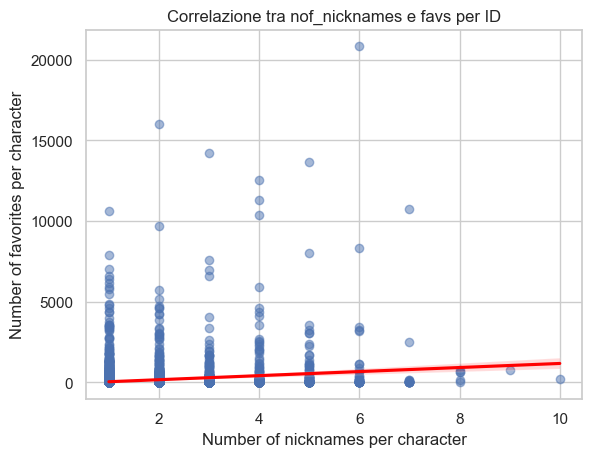

In [6]:
sns.set_theme(style="whitegrid")

sns.regplot(data=result, x='nof_nicknames', y='favs',
            scatter_kws={'alpha':0.5},
            line_kws={'color':'red'})

plt.title('Correlazione tra nof_nicknames e favs per ID')
plt.xlabel('Number of nicknames per character')
plt.ylabel('Number of favorites per character')
plt.savefig('../../graphs/avgScoreTime.png', dpi=300, bbox_inches='tight')

In [7]:
correlazione = result['nof_nicknames'].corr(result['favs'])
print(f"Il coefficiente di correlazione di Pearson è: {correlazione:.2f}")

Il coefficiente di correlazione di Pearson è: 0.18


As we can see, the correlation is very little. 0.18 is quite close to 0 so that means we cannot say the more popularity a character has, the more nicknames he has.